# CiFar10 Dataset

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow import keras
import cv2

In [1]:
from tensorflow.keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) =cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
x_train.shape

(50000, 32, 32, 3)

In [4]:
y_train.shape

(50000, 1)

In [5]:
#the number of unique train labels
unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ", dict(zip(unique, counts)))

#the number of unique test labels
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest labels: ", dict(zip(unique, counts)))

Train labels:  {0: 5000, 1: 5000, 2: 5000, 3: 5000, 4: 5000, 5: 5000, 6: 5000, 7: 5000, 8: 5000, 9: 5000}

Test labels:  {0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


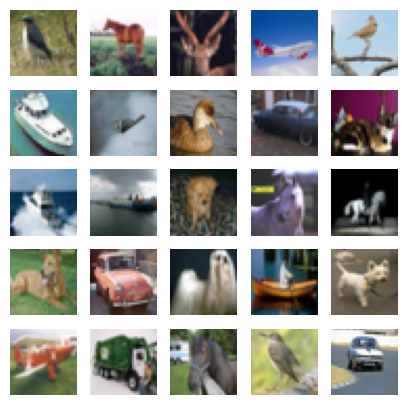

In [11]:
# Display 16 random images from train dataset

indexes = np.random.randint(0, x_train.shape[0], size=25)
images = x_train[indexes]
labels = y_train[indexes]

plt.figure(figsize=(5,5))
for i in range(len(indexes)):
    plt.subplot(5, 5, i + 1)
    image = images[i]
    plt.imshow(image, cmap='gray')
    plt.axis('off')

plt.show()
plt.savefig("cifar10-samples.png")
plt.close('all')

classes = [airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck]

In [ ]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
# image dimensions (assumed square)
image_size = x_train.shape[1]
input_size = image_size * image_size
input_size

1024

In [ ]:
# Flatten and normalize the data
x_train = np.array([image.flatten() for image in x_train]).astype('float32') / 255
x_test = np.array([image.flatten() for image in x_test]).astype('float32') / 255

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")


x_train shape: (50000, 3072)
x_test shape: (10000, 3072)


In [ ]:
model = keras.Sequential()
model.add(keras.layers.Dense(256, input_shape=(3072,)))
model.add(keras.layers.Dropout(0.45))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dropout(0.45))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dropout(0.45))
model.add(keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
learning_rate = 0.001
optimizer =tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         786,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 920,842 (3.51 MB)

 Trainable params: 920,842 (3.51 MB)

 Non-trainable params: 0 (0.00 B)

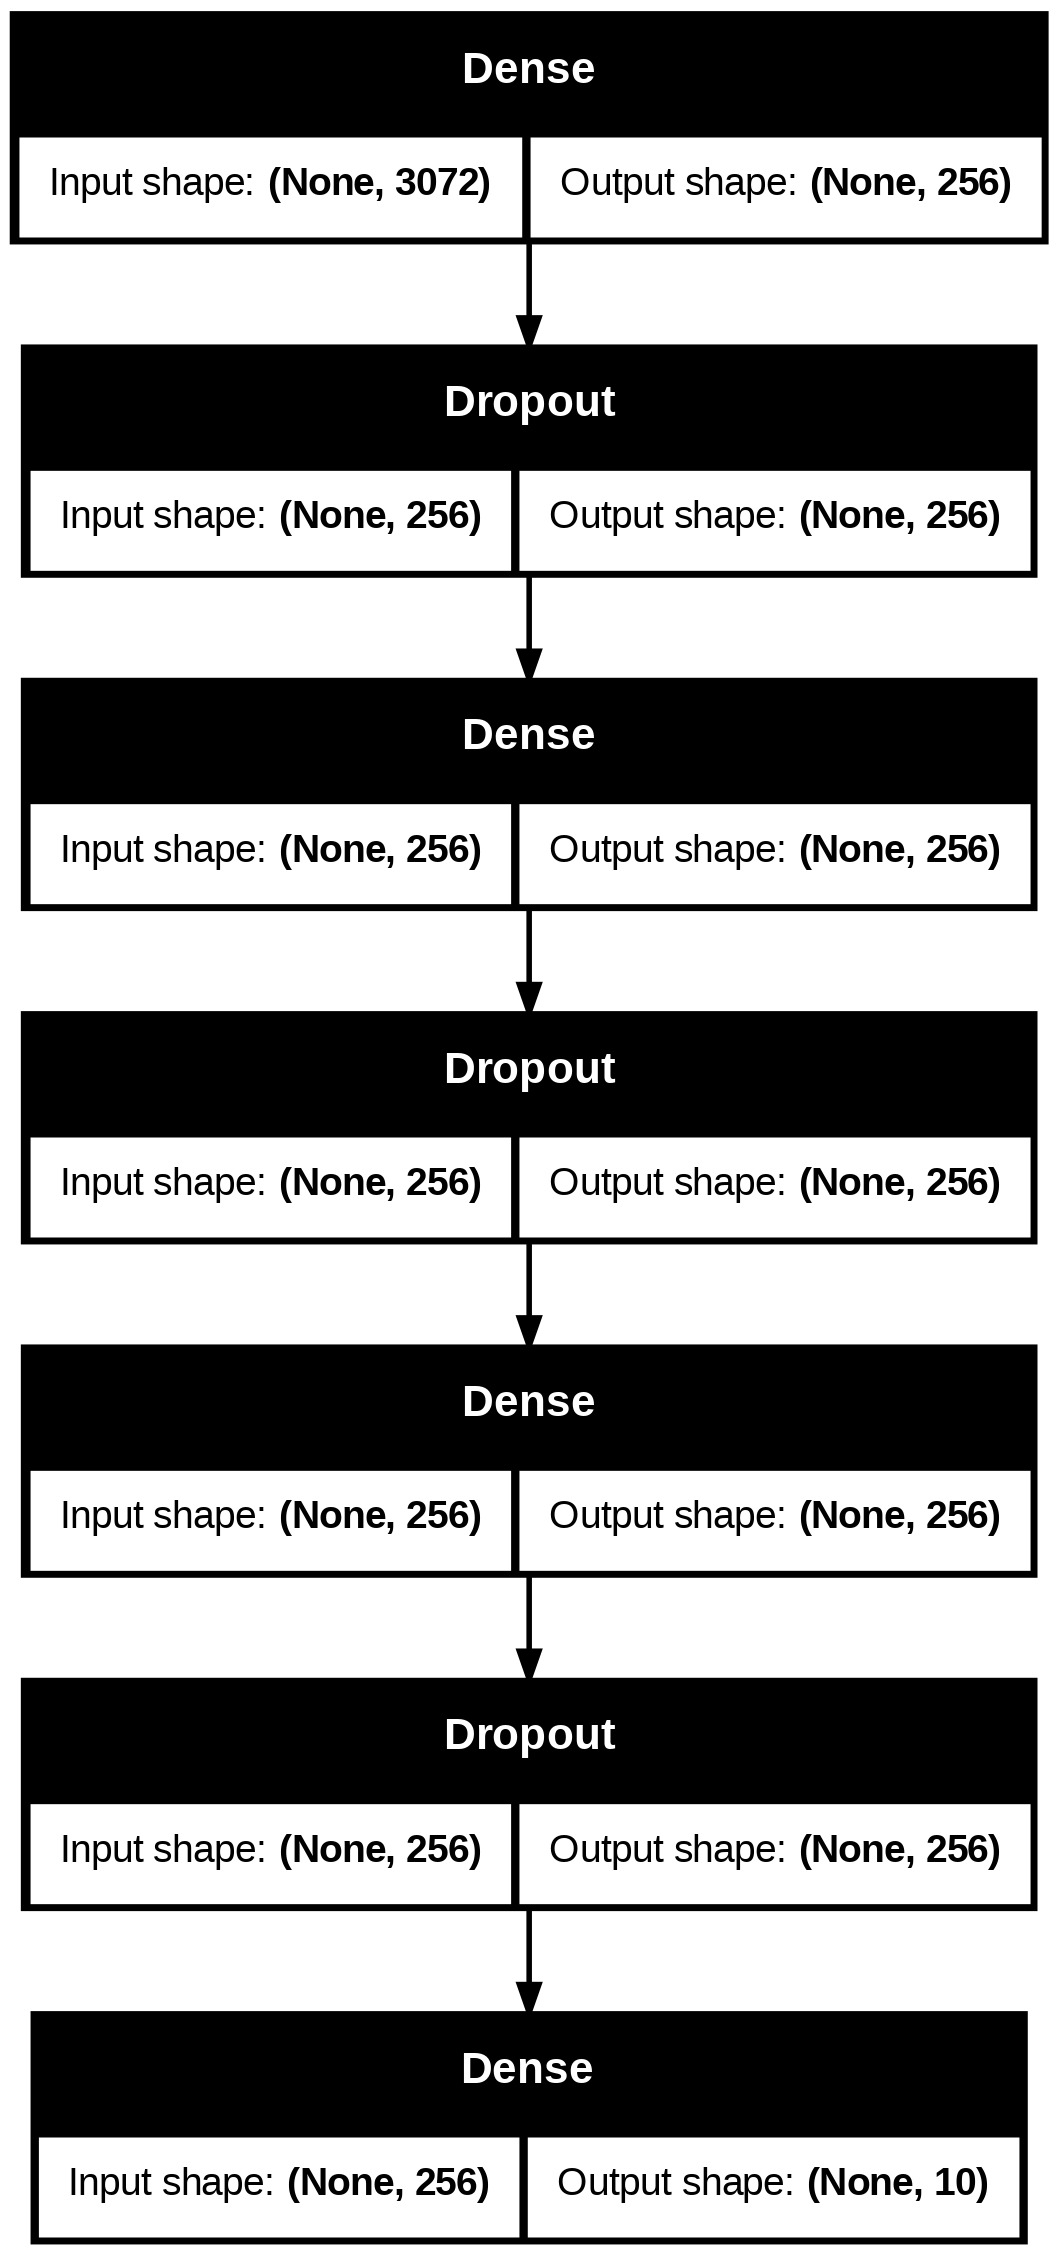

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model, to_file='mlp-cifar.png', show_shapes=True)


In [ ]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
                    epochs=6, batch_size=128)

Epoch 1/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3760 - loss: 1.7385 - val_accuracy: 0.4203 - val_loss: 1.6540
Epoch 2/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3819 - loss: 1.7398 - val_accuracy: 0.4302 - val_loss: 1.6530
Epoch 3/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3812 - loss: 1.7388 - val_accuracy: 0.4096 - val_loss: 1.6892
Epoch 4/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3833 - loss: 1.7234 - val_accuracy: 0.3999 - val_loss: 1.6939
Epoch 5/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3879 - loss: 1.7223 - val_accuracy: 0.4303 - val_loss: 1.6336
Epoch 6/6
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3896 - loss: 1.7138 - val_accuracy: 0.4291 - val_loss: 1.6298


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Test Loss: 1.6298279762268066
Test Accuracy: 0.42910000681877136


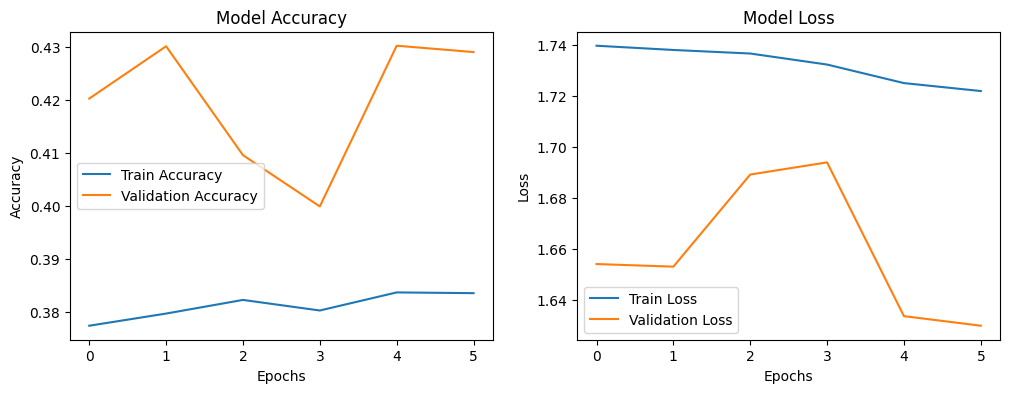

In [ ]:
plt.figure(figsize=(12, 4))
# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
predictions = model.predict(x_test, batch_size=128)
predictions

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.06383114, 0.04536818, 0.09297527, ..., 0.03498327, 0.11238539,
        0.04557268],
       [0.07721979, 0.2712212 , 0.01265624, ..., 0.00866768, 0.11167704,
        0.5032502 ],
       [0.18076105, 0.1600601 , 0.02031607, ..., 0.03154541, 0.40347564,
        0.17201723],
       ...,
       [0.01950843, 0.01157768, 0.08242777, ..., 0.03940866, 0.0259999 ,
        0.00931759],
       [0.02406101, 0.0105424 , 0.15194474, ..., 0.0403408 , 0.01087562,
        0.01363294],
       [0.06124723, 0.032278  , 0.0995973 , ..., 0.43441996, 0.01931729,
        0.06666084]], dtype=float32)

In [ ]:
y_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [ ]:

predictions = model.predict(x_test, batch_size=128)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)
true_classes

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([3, 8, 8, ..., 5, 1, 7])

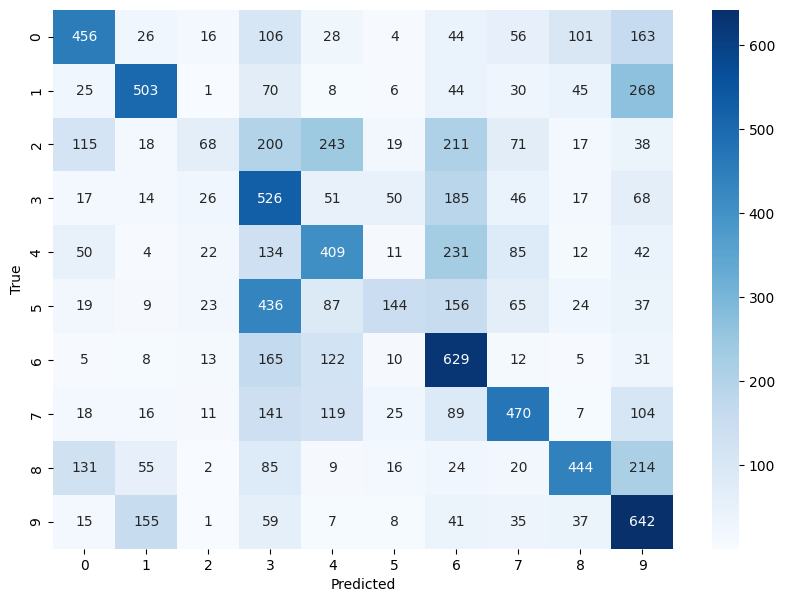

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_classes, predicted_classes)

# Visualize the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
# classification report
from sklearn.metrics import classification_report
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)
print(classification_report(y_test_classes, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.54      0.46      0.49      1000
           1       0.62      0.50      0.56      1000
           2       0.37      0.07      0.11      1000
           3       0.27      0.53      0.36      1000
           4       0.38      0.41      0.39      1000
           5       0.49      0.14      0.22      1000
           6       0.38      0.63      0.47      1000
           7       0.53      0.47      0.50      1000
           8       0.63      0.44      0.52      1000
           9       0.40      0.64      0.49      1000

    accuracy                           0.43     10000
   macro avg       0.46      0.43      0.41     10000
weighted avg       0.46      0.43      0.41     10000



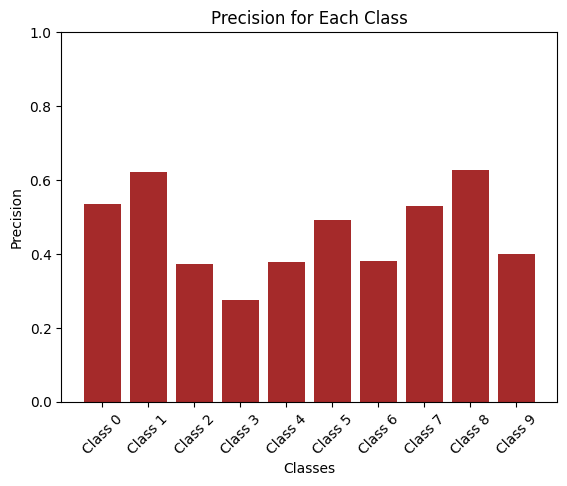

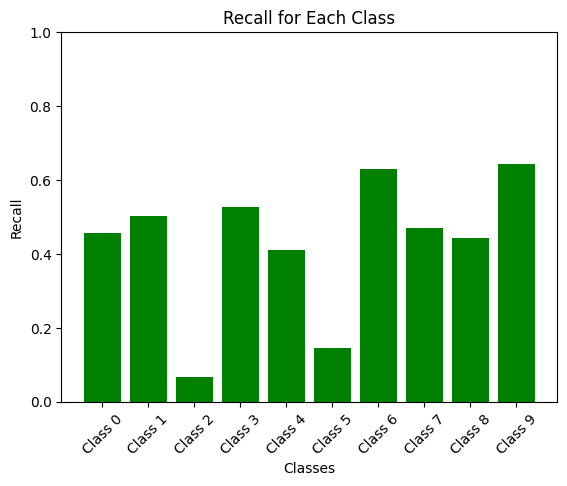

In [ ]:
# plot precision and recall
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(y_test_classes, y_pred_classes, output_dict=True)

precision = [report[str(i)]['precision'] for i in range(10)]
recall = [report[str(i)]['recall'] for i in range(10)]
classes = [f"Class {i}" for i in range(10)]

plt.bar(classes, precision, color='brown')
plt.title('Precision for Each Class')
plt.xlabel('Classes')
plt.ylabel('Precision')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

plt.bar(classes, recall, color='green')
plt.title('Recall for Each Class')
plt.xlabel('Classes')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()


In [ ]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# Define CIFAR-10 classes
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def predict_image(model, image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image file not found: {image_path}")

    # Load and preprocess the image
    image = load_img(image_path, target_size=(32, 32))
    image_array = img_to_array(image)
    image_array = image_array / 255.0
    image_array = image_array.flatten()
    image_array = np.expand_dims(image_array, axis=0)


    # Predict the class
    predictions = model.predict(image_array)
    predicted_class = np.argmax(predictions, axis=1)[0]

    return classes[predicted_class]

# Predict on an image
image_path = '/content/car1.jpg'
try:
    predicted_class = predict_image(model, image_path)
    print(f"Predicted class: {predicted_class}")
except Exception as e:
    print(e)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted class: automobile
